In [1]:
import os
import numpy as np
from plyfile import PlyData
from tqdm import tqdm

PLY_FOLDER = '../dataset/Linemod_preprocessed/models'
OUTPUT_FOLDER = 'keypoints'
NUM_KEYPOINTS = 8
CLASS_IDS = [f"{i:02d}" for i in range(1, 16) if i not in [3, 7]]  # Skip missing classes


def load_ply(path):
    ply = PlyData.read(path)
    v = ply['vertex']
    return np.stack([v['x'], v['y'], v['z']], axis=-1).astype(np.float32)

def farthest_point_sampling(points, k):
    selected = [np.random.randint(len(points))]
    distances = np.full(len(points), np.inf)

    for _ in range(1, k):
        last = points[selected[-1]]
        dist = np.linalg.norm(points - last, axis=1)
        distances = np.minimum(distances, dist)
        selected.append(np.argmax(distances))

    return points[selected]

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    for cls_id in tqdm(CLASS_IDS, desc="Extracting keypoints"):
        ply_path = os.path.join(PLY_FOLDER, f"obj_{cls_id}.ply")
        if not os.path.exists(ply_path):
            print(f"[SKIP] Missing: obj_{cls_id}.ply")
            continue

        points = load_ply(ply_path)
        keypoints = farthest_point_sampling(points, NUM_KEYPOINTS)
        np.save(os.path.join(OUTPUT_FOLDER, f"obj_{cls_id}_keypoints.npy"), keypoints)

    print(f"\n✅ Saved keypoints for {len(CLASS_IDS)} objects in '{OUTPUT_FOLDER}'")

if __name__ == "__main__":
    main()


Extracting keypoints: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  2.79it/s]


✅ Saved keypoints for 13 objects in 'keypoints'


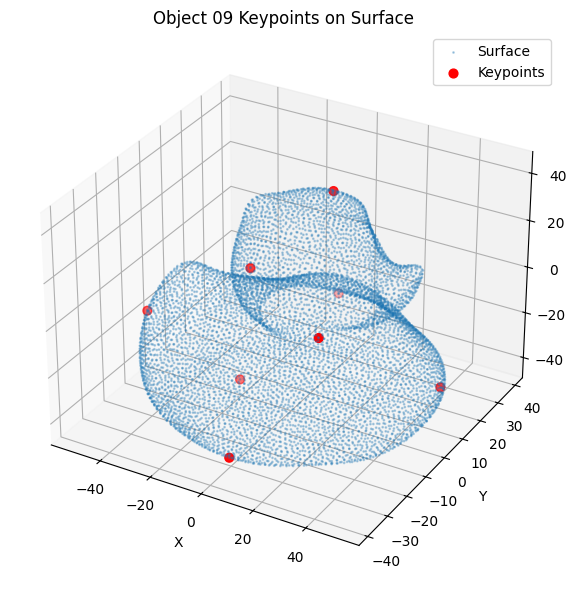

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ========== CONFIGURATION ==========
PLY_FOLDER = '../dataset/Linemod_preprocessed/models'
KEYPOINT_FOLDER = 'keypoints'
CLASS_ID = '09'  # Change this to any valid ID like '02', '04', etc.
# ===================================

def load_ply(path):
    ply = PlyData.read(path)
    v = ply['vertex']
    return np.stack([v['x'], v['y'], v['z']], axis=-1).astype(np.float32)

def main():
    ply_path = os.path.join(PLY_FOLDER, f"obj_{CLASS_ID}.ply")
    kp_path = os.path.join(KEYPOINT_FOLDER, f"obj_{CLASS_ID}_keypoints.npy")

    if not os.path.exists(ply_path) or not os.path.exists(kp_path):
        print("Missing file(s)")
        return

    points = load_ply(ply_path)
    keypoints = np.load(kp_path)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, alpha=0.3, label='Surface')
    ax.scatter(keypoints[:, 0], keypoints[:, 1], keypoints[:, 2], color='r', s=40, label='Keypoints')

    ax.set_title(f"Object {CLASS_ID} Keypoints on Surface")
    ax.legend()
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()

In [7]:
import cv2
import yaml

LINEMOD_ROOT = '../dataset/Linemod_preprocessed/data'
KEYPOINT_FOLDER = 'keypoints'
OUTPUT_LABEL_FOLDER = 'pvnet_labels'
CAMERA_INTRINSICS = np.array([[572.4114, 0, 325.2611],
                              [0, 573.57043, 242.04899],
                              [0, 0, 1]], dtype=np.float32)
NUM_KEYPOINTS = 8
IMG_SIZE = (480, 640)
SKIP_CLASSES = ['03', '07']
# =====================

def load_yaml(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

def project_points(points_3d, R, t, K):
    pts_cam = R @ points_3d.T + t.reshape(3, 1)  # [3, N]
    pts_2d = K @ pts_cam
    pts_2d = pts_2d[:2] / pts_2d[2]
    return pts_2d.T  # [N, 2]

def generate_label(mask, keypoints_2d):
    h, w = mask.shape
    vector_field = np.zeros((NUM_KEYPOINTS, 2, h, w), dtype=np.float32)
    visibility = np.zeros((NUM_KEYPOINTS,), dtype=np.uint8)

    ys, xs = np.where(mask > 0)  # foreground pixels
    for i, kp in enumerate(keypoints_2d):
        visibility[i] = 1
        for y, x in zip(ys, xs):
            direction = kp - np.array([x, y], dtype=np.float32)
            norm = np.linalg.norm(direction) + 1e-6
            unit_vector = direction / norm
            vector_field[i, :, y, x] = unit_vector

    return vector_field, visibility

def main():
    os.makedirs(OUTPUT_LABEL_FOLDER, exist_ok=True)

    for cls_id in tqdm([f"{i:02d}" for i in range(1, 16) if f"{i:02d}" not in SKIP_CLASSES]):
        class_path = os.path.join(LINEMOD_ROOT, cls_id)
        rgb_folder = os.path.join(class_path, 'rgb')
        mask_folder = os.path.join(class_path, 'mask')
        gt_path = os.path.join(class_path, 'gt.yml')
        train_list = os.path.join(class_path, 'train.txt')
        keypoint_path = os.path.join(KEYPOINT_FOLDER, f"obj_{cls_id}_keypoints.npy")

        if not os.path.exists(gt_path) or not os.path.exists(keypoint_path):
            print(f"[SKIP] Missing gt.yml or keypoints for class {cls_id}")
            continue

        keypoints_3d = np.load(keypoint_path)
        gt_data = load_yaml(gt_path)

        with open(train_list, 'r') as f:
            image_ids = [line.strip() for line in f if line.strip()]

        for img_id in image_ids:
            rgb_path = os.path.join(rgb_folder, f"{img_id}.png")
            mask_path = os.path.join(mask_folder, f"{img_id}.png")
            if not os.path.exists(rgb_path) or not os.path.exists(mask_path):
                continue

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            obj_entry = gt_data[int(img_id)][0]
            R = np.array(obj_entry['cam_R_m2c']).reshape(3, 3)
            t = np.array(obj_entry['cam_t_m2c']) / 1000.0  # mm → meters

            keypoints_2d = project_points(keypoints_3d, R, t, CAMERA_INTRINSICS)
            vec_field, visibility = generate_label(mask, keypoints_2d)

            np.savez_compressed(os.path.join(OUTPUT_LABEL_FOLDER, f"{cls_id}_{img_id}.npz"),
                                vector_field=vec_field, visibility=visibility,
                                keypoints_2d=keypoints_2d)

    print(f"\n Saved PVNet supervision labels to '{OUTPUT_LABEL_FOLDER}'")

if __name__ == '__main__':
    main()


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [13:34<00:00, 62.67s/it]


 Saved PVNet supervision labels to 'pvnet_labels'


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models

# ========================
# CONFIGURATION
# ========================
NUM_KEYPOINTS = 8
BACKBONE = 'resnet18'  # or use lightweight encoders
PRETRAINED = True
# ========================

class PVNet(nn.Module):
    def __init__(self, num_keypoints=NUM_KEYPOINTS, pretrained=PRETRAINED):
        super(PVNet, self).__init__()

        # Backbone: ResNet18 (remove last two layers)
        resnet = models.resnet18(pretrained=pretrained)
        self.backbone = nn.Sequential(
            resnet.conv1,  # [B, 64, H/2, W/2]
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # [B, 64, H/4, W/4]
            resnet.layer2,  # [B, 128, H/8, W/8]
            resnet.layer3,  # [B, 256, H/16, W/16]
            resnet.layer4   # [B, 512, H/32, W/32]
        )

        # Decoder: upsample to original resolution
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 1/16
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1/8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 1/4
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 1/2
            nn.ReLU(),
            nn.ConvTranspose2d(32, num_keypoints * 2, kernel_size=4, stride=2, padding=1)  # Final upsample
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.decoder(features)
        return out  # [B, N*2, H, W]

In [13]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

DATA_FOLDER = '../dataset/Linemod_preprocessed/data'
LABEL_FOLDER = 'pvnet_labels'
NUM_KEYPOINTS = 8
EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
IMG_SIZE = (480, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset class 
class PVNetDataset(Dataset):
    def __init__(self, label_dir, data_root):
        self.label_dir = label_dir
        self.data_root = data_root
        self.label_files = [f for f in os.listdir(label_dir) if f.endswith('.npz')]

        self.transform = transforms.Compose([
            transforms.Resize(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.label_files)

    def __getitem__(self, idx):
        label_file = self.label_files[idx]
        cls_id, img_id = label_file.replace('.npz', '').split('_')
        rgb_path = os.path.join(self.data_root, cls_id, 'rgb', f"{img_id}.png")

        # Load image and label
        image = Image.open(rgb_path).convert('RGB')
        image = self.transform(image)

        label = np.load(os.path.join(self.label_dir, label_file))
        vec_field = label['vector_field']    # [N, 2, H, W]
        visibility = label['visibility']     # [N]

        vec_field = torch.tensor(vec_field, dtype=torch.float32)
        visibility = torch.tensor(visibility, dtype=torch.bool)

        return image, vec_field, visibility

# === Loss function ===
def cosine_loss(pred, target, mask):
    """
    pred: [B, N, 2, H, W]
    target: [B, N, 2, H, W]
    mask: [B, N, H, W]
    """
    pred_norm = torch.nn.functional.normalize(pred, dim=2)
    target_norm = torch.nn.functional.normalize(target, dim=2)

    cos_sim = (pred_norm * target_norm).sum(2)  # [B, N, H, W]
    loss = 1 - cos_sim
    return (loss * mask.float()).sum() / (mask.sum() + 1e-6)

# Training Setup
model = PVNet(NUM_KEYPOINTS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

dataset = PVNetDataset(LABEL_FOLDER, DATA_FOLDER)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, vec_fields, visibility in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(DEVICE)
        vec_fields = vec_fields.to(DEVICE)
        visibility = visibility.to(DEVICE)

        optimizer.zero_grad()

        pred = model(images)  # [B, N*2, H, W]
        B, _, H, W = pred.shape
        pred = pred.view(B, NUM_KEYPOINTS, 2, H, W)

        # Visibility mask → [B, N, H, W]
        mask = (vec_fields.abs().sum(2) > 0) & visibility.unsqueeze(-1).unsqueeze(-1)

        loss = cosine_loss(pred, vec_fields, mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"✅ Epoch {epoch+1} — Avg Loss: {avg_loss:.6f}")

# Save model
torch.save(model.state_dict(), "pvnet_model.pth")
print("Model saved")

/home/erythm/anaconda3/envs/6d/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erythm/anaconda3/envs/6d/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [03:58<00:00,  2.49it/s]


✅ Epoch 1 — Avg Loss: 0.867079


Epoch 2/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [03:58<00:00,  2.49it/s]


✅ Epoch 2 — Avg Loss: 0.782336


Epoch 3/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [03:57<00:00,  2.50it/s]


...

✅ Epoch 18 — Avg Loss: 0.238656


Epoch 19/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [03:57<00:00,  2.50it/s]


✅ Epoch 19 — Avg Loss: 0.221794


Epoch 20/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [03:57<00:00,  2.50it/s]


✅ Epoch 20 — Avg Loss: 0.211905
Model saved
